In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [4]:

df = pd.read_csv("bank_transactions_data.csv")
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df = df.sort_values(['AccountID', 'TransactionDate']).reset_index(drop=True)
print("Shape:", df.shape, "| Unique accounts:", df['AccountID'].nunique())
print("Nulls:", df.isnull().sum().sum())
print(df[['TransactionAmount','LoginAttempts','AccountBalance']].describe().round(2))


Shape: (2512, 16) | Unique accounts: 495
Nulls: 0
       TransactionAmount  LoginAttempts  AccountBalance
count            2512.00        2512.00         2512.00
mean              297.59           1.12         5114.30
std               291.95           0.60         3900.94
min                 0.26           1.00          101.25
25%                81.89           1.00         1504.37
50%               211.14           1.00         4735.51
75%               414.53           1.00         7678.82
max              1919.11           5.00        14977.99


In [5]:

# (a) PreviousTransactionDate - is this really "this account's prior transaction"?
print("PreviousTransactionDate range:", df['PreviousTransactionDate'].min(), "to", df['PreviousTransactionDate'].max())
print("TransactionDate range:        ", df['TransactionDate'].min(), "to", df['TransactionDate'].max())

PreviousTransactionDate range: 2024-11-04 08:06:23 to 2024-11-04 08:12:23
TransactionDate range:         2023-01-02 16:00:06 to 2024-01-01 18:21:50


In [6]:

# (b) Does DeviceID/Location repeat per account, or is every transaction a "new" device?
seen = {}
new_device_flags = []
for _, row in df.iterrows():
    s = seen.setdefault(row['AccountID'], set())
    new_device_flags.append(0 if row['DeviceID'] in s else 1)
    s.add(row['DeviceID'])
print("Share of transactions using a device never seen before for that account:",
      f"{np.mean(new_device_flags):.1%}")


Share of transactions using a device never seen before for that account: 99.5%


In [7]:

# (c) Does transaction hour actually vary across a real day?
print(df['TransactionDate'].dt.hour.value_counts().sort_index())

TransactionDate
16    1316
17     819
18     377
Name: count, dtype: int64


In [8]:

acc_stats = df.groupby('AccountID')['TransactionAmount'].agg(['mean','std'])
global_std = df['TransactionAmount'].std()
acc_stats['std'] = acc_stats['std'].fillna(global_std).replace(0, global_std)  # accounts with 1 txn or constant amount
df = df.merge(acc_stats.rename(columns={'mean':'acc_mean','std':'acc_std'}), on='AccountID', how='left')

df['amount_zscore'] = (df['TransactionAmount'] - df['acc_mean']) / df['acc_std']
df['amount_to_balance_ratio'] = (df['TransactionAmount'] / df['AccountBalance'].replace(0, np.nan)).fillna(0)
df['transaction_hour'] = df['TransactionDate'].dt.hour

print(df[['amount_zscore','amount_to_balance_ratio']].describe().round(2))

       amount_zscore  amount_to_balance_ratio
count        2512.00                  2512.00
mean            0.00                     0.20
std             0.90                     0.51
min            -1.95                     0.00
25%            -0.71                     0.02
50%            -0.24                     0.05
75%             0.66                     0.15
max             2.67                     7.90


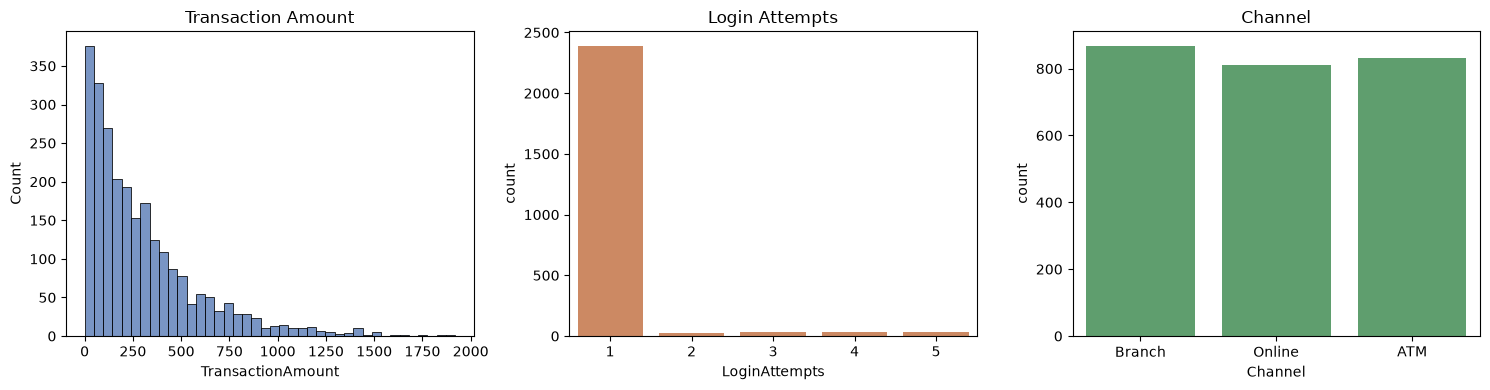

In [21]:

fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df['TransactionAmount'], bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title("Transaction Amount")
sns.countplot(x='LoginAttempts', data=df, ax=axes[1], color='#DD8452')
axes[1].set_title("Login Attempts")
sns.countplot(x='Channel', data=df, ax=axes[2], color='#55A868')
axes[2].set_title("Channel")
plt.tight_layout(); plt.show()

In [22]:

feature_cols_num = ['TransactionAmount','amount_zscore','amount_to_balance_ratio','AccountBalance',
                     'TransactionDuration','LoginAttempts','CustomerAge','transaction_hour']

def build_matrix(frame):
    X = frame[feature_cols_num].copy()
    X = pd.concat([X, pd.get_dummies(frame['TransactionType'], prefix='type'),
                      pd.get_dummies(frame['Channel'], prefix='chan')], axis=1)
    return X

X = build_matrix(df)
X_scaled = StandardScaler().fit_transform(X)

iso = IsolationForest(n_estimators=300, contamination=0.03, random_state=42)
iso.fit(X_scaled)
df['anomaly_score'] = -iso.score_samples(X_scaled)  # higher = more anomalous
print("Score range:", df['anomaly_score'].min().round(3), "to", df['anomaly_score'].max().round(3))
print(df.sort_values('anomaly_score', ascending=False)[['AccountID','TransactionAmount','amount_zscore','LoginAttempts','anomaly_score']].head(5))

Score range: 0.419 to 0.702
     AccountID  TransactionAmount  amount_zscore  LoginAttempts  anomaly_score
2290   AC00454            1176.28       1.448973              5       0.701927
429    AC00083            1531.31       1.869265              4       0.672373
2367   AC00466            1342.25       1.192343              1       0.670230
670    AC00131             879.25       2.235553              1       0.660421
2299   AC00456            1022.75       2.408272              1       0.655391


In [23]:

df['rule_score'] = ((df['amount_zscore'].abs() > 2).astype(int)
                     + (df['LoginAttempts'] >= 4).astype(int)
                     + (df['amount_to_balance_ratio'] > df['amount_to_balance_ratio'].quantile(0.95)).astype(int))

k = int(len(df) * 0.05)
top_iso = set(df.sort_values('anomaly_score', ascending=False).head(k).index)
top_rule = set(df.sort_values('rule_score', ascending=False).head(k).index)
overlap = len(top_iso & top_rule)
print(f"Top-5% by Isolation Forest vs top-5% by rule score: {overlap}/{k} transactions in common ({overlap/k:.0%})")

Top-5% by Isolation Forest vs top-5% by rule score: 45/125 transactions in common (36%)


In [24]:

n_each = 15
pool = df.sample(n_each * 3, random_state=7).reset_index(drop=True)
typeA = pool.iloc[:n_each].copy()          # amount spike only (moderate, 2.5-4x)
typeB = pool.iloc[n_each:2*n_each].copy()  # login-attempts spike only
typeC = pool.iloc[2*n_each:].copy()        # both signals, stronger

typeA['TransactionAmount'] = typeA['acc_mean'] + np.random.uniform(2.5, 4, n_each) * typeA['acc_std'].abs()
typeB['LoginAttempts'] = np.random.choice([4, 5], n_each)
typeC['TransactionAmount'] = typeC['acc_mean'] + np.random.uniform(3, 5, n_each) * typeC['acc_std'].abs()
typeC['LoginAttempts'] = np.random.choice([4, 5], n_each)

synth = pd.concat([typeA, typeB, typeC], ignore_index=True)
synth['amount_zscore'] = (synth['TransactionAmount'] - synth['acc_mean']) / synth['acc_std']
synth['amount_to_balance_ratio'] = (synth['TransactionAmount'] / synth['AccountBalance'].replace(0, np.nan)).fillna(0)
synth['synth_type'] = ['amount_spike']*n_each + ['login_spike']*n_each + ['both']*n_each

combined = pd.concat([df.assign(is_synthetic=0, synth_type='real'),
                       synth.assign(is_synthetic=1)], ignore_index=True)
X_c = build_matrix(combined)
X_c_scaled = StandardScaler().fit_transform(X_c)

iso2 = IsolationForest(n_estimators=300, contamination=0.03, random_state=42)
iso2.fit(X_c_scaled)
combined['anomaly_score'] = -iso2.score_samples(X_c_scaled)
combined = combined.sort_values('anomaly_score', ascending=False).reset_index(drop=True)

for pct in [0.03, 0.05, 0.10]:
    kk = int(len(combined) * pct)
    det = combined.head(kk)['is_synthetic'].sum()
    print(f"Reviewing top {pct:.0%} of transactions by score catches {det}/{len(synth)} injected anomalies ({det/len(synth):.0%})")

print()
print("Avg anomaly score by type:")
print(combined[combined['is_synthetic']==1].groupby('synth_type')['anomaly_score'].mean().round(3))
print("Avg anomaly score, real transactions:", combined[combined['is_synthetic']==0]['anomaly_score'].mean().round(3))

Reviewing top 3% of transactions by score catches 21/45 injected anomalies (47%)
Reviewing top 5% of transactions by score catches 26/45 injected anomalies (58%)
Reviewing top 10% of transactions by score catches 31/45 injected anomalies (69%)

Avg anomaly score by type:
synth_type
amount_spike    0.571
both            0.645
login_spike     0.566
Name: anomaly_score, dtype: float64
Avg anomaly score, real transactions: 0.485


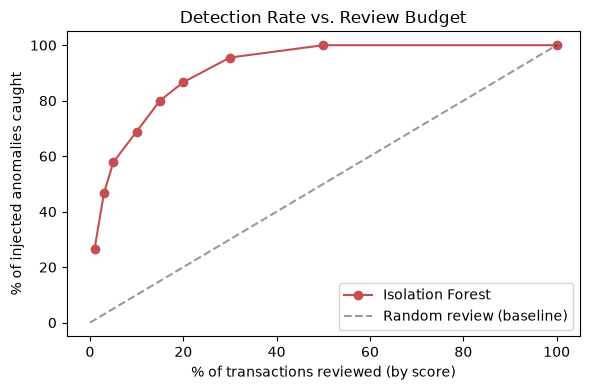

In [25]:

plt.figure(figsize=(6,4))
pcts = [0.01,0.03,0.05,0.10,0.15,0.20,0.30,0.50,1.0]
rates = []
for p in pcts:
    kk = max(1, int(len(combined) * p))
    rates.append(combined.head(kk)['is_synthetic'].sum() / len(synth) * 100)
plt.plot([p*100 for p in pcts], rates, marker='o', color='#C44E52', label='Isolation Forest')
plt.plot([0,100],[0,100],'k--', alpha=0.4, label='Random review (baseline)')
plt.xlabel("% of transactions reviewed (by score)")
plt.ylabel("% of injected anomalies caught")
plt.title("Detection Rate vs. Review Budget")
plt.legend(); plt.tight_layout(); plt.show()



In [19]:

# Requires ANTHROPIC_API_KEY. Illustrative only.
'''
import anthropic
client = anthropic.Anthropic()

def explain_flag(row):
    prompt = (f"A transaction was flagged as anomalous. Amount z-score vs this account's "
              f"history: {row['amount_zscore']:.1f}, login attempts: {row['LoginAttempts']}, "
              f"amount/balance ratio: {row['amount_to_balance_ratio']:.2f}. "
              f"In one sentence, explain why in plain English for a fraud analyst.")
    resp = client.messages.create(model="claude-sonnet-4-6", max_tokens=60,
                                   messages=[{"role":"user","content":prompt}])
    return resp.content[0].text

for _, row in df.sort_values('anomaly_score', ascending=False).head(5).iterrows():
    print(explain_flag(row))
'''
print("(Illustrative cell — requires ANTHROPIC_API_KEY and network access to run.)")


(Illustrative cell — requires ANTHROPIC_API_KEY and network access to run.)
